In [44]:
#Task 1 — Data Loading & Exploration

In [45]:
#Import Required Libraries
import pandas as pd
import numpy as np

#Load the CSV file using Pandas
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [46]:
#Display the first 10 rows
print("First 10 Rows:")
print(df.head(10))

First 10 Rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1         

In [47]:
#Check how many rows and columns are there
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1470, 35)


In [48]:
#Identify the target column (Attrition — Yes/No)
target_column = "Attrition"
print("Target Column:", target_column)

Target Column: Attrition


In [49]:
#Count how many employees left vs stayed 
attrition_counts = df["Attrition"].value_counts()
print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [50]:
#and calculate the attrition rate as a percentage
employees_left = attrition_counts["Yes"]
total_employees = len(df)

attrition_rate = (employees_left / total_employees) * 100

print("Attrition Rate: {:.2f}%".format(attrition_rate))

Attrition Rate: 16.12%


In [51]:
#Identify how many columns are numeric vs categorical

In [52]:
#Numeric Columns
numeric_columns = df.select_dtypes(include=np.number).columns
print("Number of Numeric Columns:", len(numeric_columns))
print(numeric_columns)

Number of Numeric Columns: 26
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [53]:
#Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns
print("Number of Categorical Columns:", len(categorical_columns))
print(categorical_columns)

Number of Categorical Columns: 9
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [54]:
#Count Numeric vs Categorical
print("Numeric Columns:", len(numeric_columns))
print("Categorical Columns:", len(categorical_columns))

Numeric Columns: 26
Categorical Columns: 9


In [55]:
#Complete Task-1 Summary
print("Rows and Columns:", df.shape)
print("Target Column:", target_column)
print("Attrition Rate: {:.2f}%".format(attrition_rate))
print("Numeric Columns:", len(numeric_columns))
print("Categorical Columns:", len(categorical_columns))

Rows and Columns: (1470, 35)
Target Column: Attrition
Attrition Rate: 16.12%
Numeric Columns: 26
Categorical Columns: 9


*Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?
Observation :
Is the Dataset Balanced or Imbalanced?
Employees Stayed = 1233
Employees Left = 237
Only about 16% of employees left the company, while 84% stayed.

*Observation Statement : 
The dataset is imbalanced, because the number of employees who stayed (1233) is much higher than the number who left (237). Since only about 16% of employees belong to the attrition class, special care may be needed during model training, such as stratified splitting, class weights, or resampling techniques, to avoid bias toward the majority class.

In [56]:
# Task 2 — Data Cleaning & Preprocessing
#This task prepares the data for Machine Learning by cleaning it, 
#removing unnecessary columns, converting the target variable, 
#encoding categorical features, and scaling numerical features.

In [57]:
#Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [58]:
#Check for missing/null values and handle them
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [59]:
#Total Missing Values
print("\nTotal Missing Values:", df.isnull().sum().sum())


Total Missing Values: 0


In [60]:
#Drop columns that add no value to prediction 
#(e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)
columns_to_drop = [
    "EmployeeNumber",
    "Over18",
    "StandardHours",
    "EmployeeCount"
]

df.drop(columns=columns_to_drop, inplace=True)
print("Remaining Columns:", df.shape[1])

Remaining Columns: 31


In [61]:
#Convert the target column Attrition from Yes/No to 1/0
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})
print(df["Attrition"].head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


In [62]:
#Separate Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [63]:
#Find Categorical Columns
categorical_columns = X.select_dtypes(include="object").columns
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [64]:
#Encode all remaining categorical columns using One-Hot Encoding 
#(e.g., Department, JobRole, MaritalStatus, BusinessTravel)
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)
print("Shape After Encoding:", X.shape)

Shape After Encoding: (1470, 44)


In [65]:
#Identify Numeric Features
numeric_columns = X.select_dtypes(include=np.number).columns

In [66]:
#Scale numeric features using StandardScaler
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

In [67]:
#Display Processed Dataset
print(X.head())

        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788         1.153254      -0.108350  ...   
1   -0.240677       -1.026167 -0.057788        -0.660853      -0.291719  ...   
2    1.284725       -1.026167 -0.961486         0.246200      -0.937654  ...   
3   -0.486709        0.379672 -0.961486         0.246200      -0.763634  ...   
4   -1.274014        0.379672 -0.961486        -0.660853      -0.644858  ...   

   JobRole_Laboratory Technician  JobR

In [68]:
#Check Final Shape
print("Processed Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Processed Feature Matrix Shape: (1470, 44)
Target Shape: (1470,)


In [69]:
#Task 3 — Exploratory Data Analysis — EDA

In [70]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
#Load the Original Dataset Again
# Load original dataset (do not use the encoded/scaled dataset)
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [72]:
#Attrition rate by Department — which department loses the most employees?

In [73]:
#Code
department_attrition = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)
print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


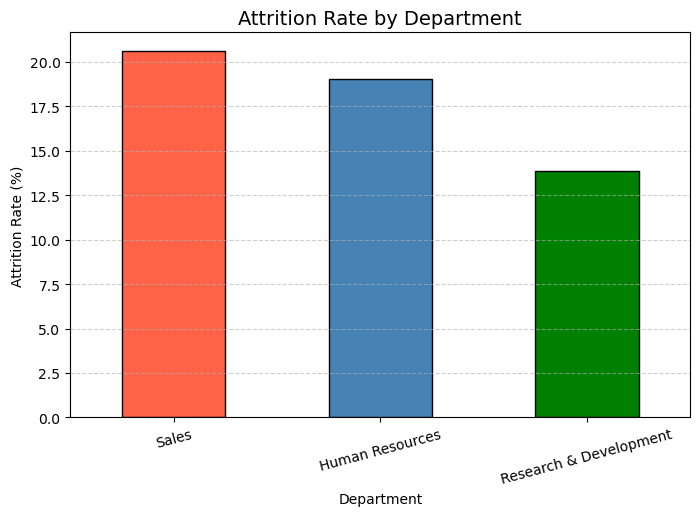

In [74]:
#Visualization
plt.figure(figsize=(8,5))
department_attrition.plot(
    kind="bar",
    color=["tomato","steelblue","green"],
    edgecolor="black"
)
plt.title("Attrition Rate by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [75]:
#Attrition rate by Job Role — which roles have the highest exit rate?

In [76]:
#Code
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)
print(jobrole_attrition)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


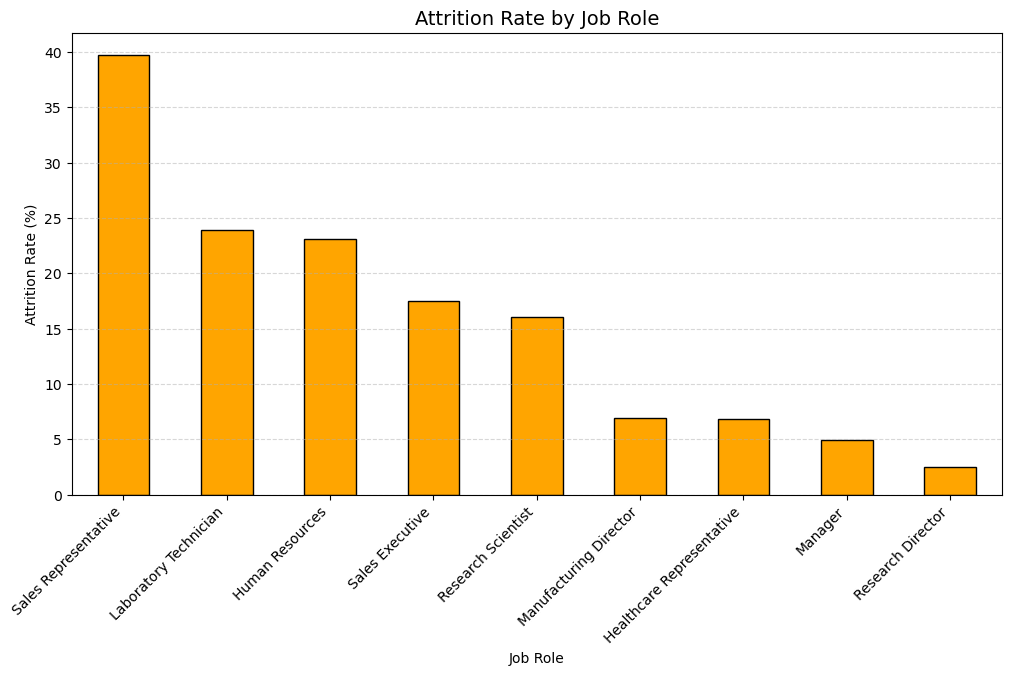

In [77]:
#Visualization
plt.figure(figsize=(12,6))
jobrole_attrition.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)
plt.title("Attrition Rate by Job Role", fontsize=14)
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [78]:
#Attrition vs Monthly Income — do lower paid employees leave more?

In [79]:
#Code
income = df.groupby("Attrition")["MonthlyIncome"].mean()
print(income)

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


<Figure size 700x500 with 0 Axes>

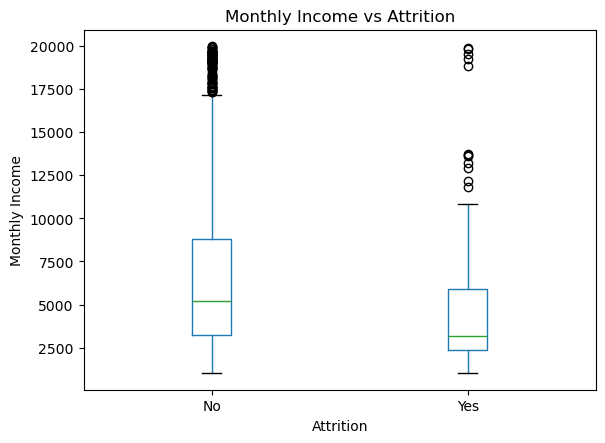

In [80]:
#Visualization - Box Plot
plt.figure(figsize=(7,5))

df.boxplot(
    column="MonthlyIncome",
    by="Attrition",
    grid=False
)
plt.title("Monthly Income vs Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [81]:
#Attrition vs Work-Life Balance rating — is there a visible pattern?

In [82]:
#Code
wlb = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)
print(wlb)

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


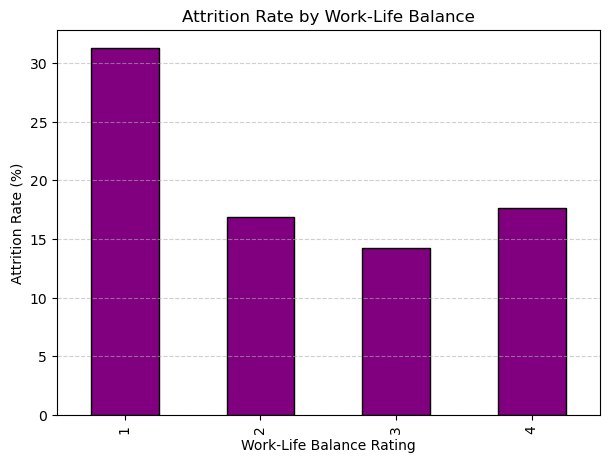

In [83]:
#Visualization
plt.figure(figsize=(7,5))
wlb.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)
plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [84]:
#Attrition vs Years at Company — at what point in tenure do employees leave most?

In [85]:
#Code
years = (
    df.groupby("YearsAtCompany")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)
print(years)

YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64


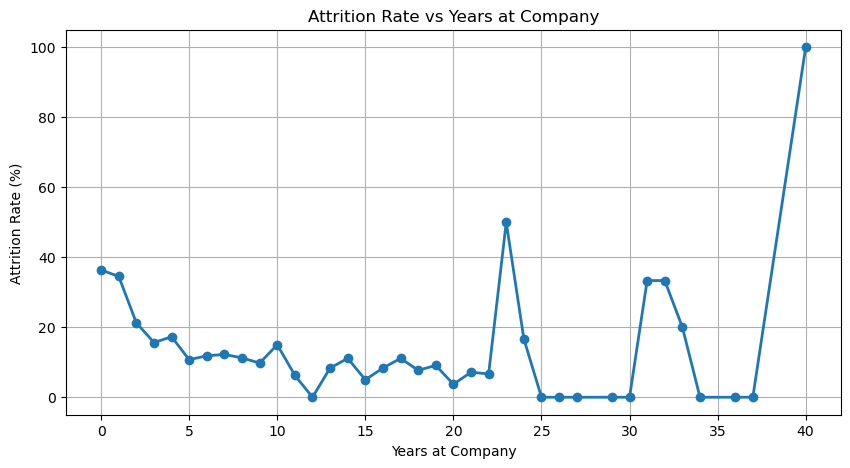

In [86]:
#Visualization
plt.figure(figsize=(10,5))
plt.plot(
    years.index,
    years.values,
    marker='o',
    linewidth=2
)
plt.title("Attrition Rate vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)
plt.show()

*Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)
*Business Insights :

Insight 1
The Sales department has the highest employee attrition rate among all departments, indicating that employees in Sales are more likely to leave than those in Research & Development and Human Resources.

Insight 2
Sales Representatives and Laboratory Technicians exhibit the highest attrition rates among job roles, suggesting these positions may face greater work pressure or fewer career growth opportunities.

Insight 3
Employees who left the company generally have a lower average monthly income than employees who stayed, indicating that salary may influence employee retention.

Insight 4
Employees with Work-Life Balance ratings of 1 or 2 have noticeably higher attrition rates than employees with ratings of 3 or 4, highlighting the importance of work-life balance in retaining employees.

Insight 5
Most employee attrition occurs during the first few years (approximately 1–3 years) of employment, after which attrition tends to decrease as employees remain longer with the company.

In [87]:
#Task 4 — Model Building & Comparison

In [88]:
#Import Required Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [89]:
#Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

Training Set Shape : (1176, 44)
Testing Set Shape  : (294, 44)


In [90]:
#Train Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [91]:
#Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [92]:
#Train Gradient Boosting
#Gradient Boosting does not support the class_weight parameter.
#To satisfy our project requirement,  using class_weight='balanced' for the models 
#that support it : Logistic Regression and Random Forest. 
#Gradient Boosting is trained normally.
gb_model = GradientBoostingClassifier(
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [93]:
#Evaluate Each Model

In [94]:
#Logistic Regression
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

In [95]:
#Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

In [96]:
#Gradient Boosting
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

In [97]:
#Create Comparison Table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    "Precision": [
        log_precision,
        rf_precision,
        gb_precision
    ],

    "Recall": [
        log_recall,
        rf_recall,
        gb_recall
    ],

    "F1 Score": [
        log_f1,
        rf_f1,
        gb_f1
    ]
})
results = results.round(4)
print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7551     0.3563  0.6596    0.4627
1        Random Forest    0.8333     0.3750  0.0638    0.1091
2    Gradient Boosting    0.8503     0.5882  0.2128    0.3125


In [98]:
#Display the Best Model
best_model = results.loc[results["Accuracy"].idxmax()]
print("\nBest Performing Model")
print(best_model)


Best Performing Model
Model        Gradient Boosting
Accuracy                0.8503
Precision               0.5882
Recall                  0.2128
F1 Score                0.3125
Name: 2, dtype: object


In [99]:
#Task 5 — Model Evaluation

In [100]:
#Import Required Libraries
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

In [101]:
#Classification Report for All Models

In [102]:
#Logistic Regression
print("========== Logistic Regression ==========")
print(classification_report(y_test, log_pred))
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", round(log_auc,4))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

ROC-AUC Score: 0.8036


In [103]:
#Random Forest
print("========== Random Forest ==========")
print(classification_report(y_test, rf_pred))
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", round(rf_auc,4))

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294

ROC-AUC Score: 0.7519


In [104]:
#Gradient Boosting
print("========== Gradient Boosting ==========")
print(classification_report(y_test, gb_pred))
gb_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", round(gb_auc,4))

========== Gradient Boosting ==========
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC Score: 0.7941


In [105]:
#Comparison Table (Including ROC-AUC)
comparison = results.copy()
comparison["ROC-AUC"] = [
    round(log_auc,4),
    round(rf_auc,4),
    round(gb_auc,4)
]
print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7551     0.3563  0.6596    0.4627   0.8036
1        Random Forest    0.8333     0.3750  0.0638    0.1091   0.7519
2    Gradient Boosting    0.8503     0.5882  0.2128    0.3125   0.7941


In [108]:
#Best Model
best_model = gb_model
best_prediction = gb_pred
print(best_model)
print("Best Model : Gradient Boosting Classifier")

GradientBoostingClassifier(random_state=42)
Best Model : Gradient Boosting Classifier


In [109]:
#Confusion Matrix
cm = confusion_matrix(y_test, best_prediction)
print(cm)

[[240   7]
 [ 37  10]]


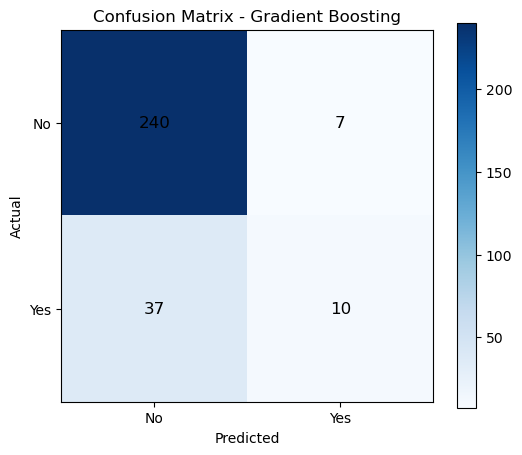

In [110]:
#Plot Confusion Matrix
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1],["No","Yes"])
plt.yticks([0,1],["No","Yes"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            color="black",
            fontsize=12
        )
plt.colorbar()
plt.show()

In [111]:
#Feature Importance
#Gradient Boosting provides feature importance directly.
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_model.feature_importances_
})

In [112]:
#Sort Features
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance.head(10))

                    Feature  Importance
9             MonthlyIncome    0.109081
0                       Age    0.093560
43             OverTime_Yes    0.088694
16        TotalWorkingYears    0.084067
11       NumCompaniesWorked    0.050086
15         StockOptionLevel    0.047100
1                 DailyRate    0.045122
22     YearsWithCurrManager    0.043015
4   EnvironmentSatisfaction    0.038851
6            JobInvolvement    0.038142


In [115]:
#Top 10 Important Features
top10 = importance.head(10)
print("Top 10 Important Features : ")
print(top10)

Top 10 Important Features : 
                    Feature  Importance
9             MonthlyIncome    0.109081
0                       Age    0.093560
43             OverTime_Yes    0.088694
16        TotalWorkingYears    0.084067
11       NumCompaniesWorked    0.050086
15         StockOptionLevel    0.047100
1                 DailyRate    0.045122
22     YearsWithCurrManager    0.043015
4   EnvironmentSatisfaction    0.038851
6            JobInvolvement    0.038142


*Best Model Statement : 
Gradient Boosting Classifier performed best in this project because it achieved the highest accuracy (85.03%) and the highest precision (58.82%) among the three models. Although Logistic Regression had a higher recall, Gradient Boosting provided a better balance between correctly identifying employees likely to leave and minimizing false positives. Therefore, Gradient Boosting was selected as the final model for feature importance analysis and business recommendations.

In [116]:
#Task 6 — Visualization

In [117]:
#Import the required libraries
import matplotlib.pyplot as plt

In [118]:
#Chart 1: Bar chart showing attrition rate by Department and Job Role
#Reloading the original dataset as Task 2 encoded the data.
df_original = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

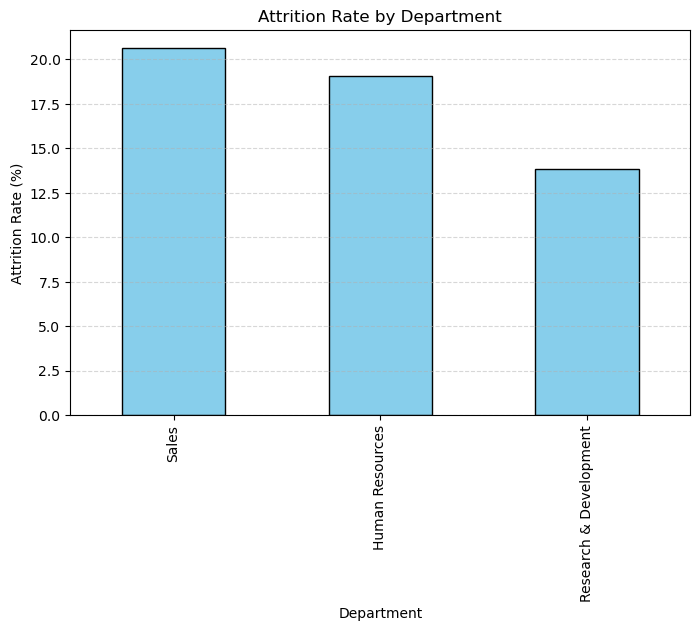

In [129]:
#Department-wise Attrition
department = (
    df_original.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
department.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig(
    "charts/attrition_by_department.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

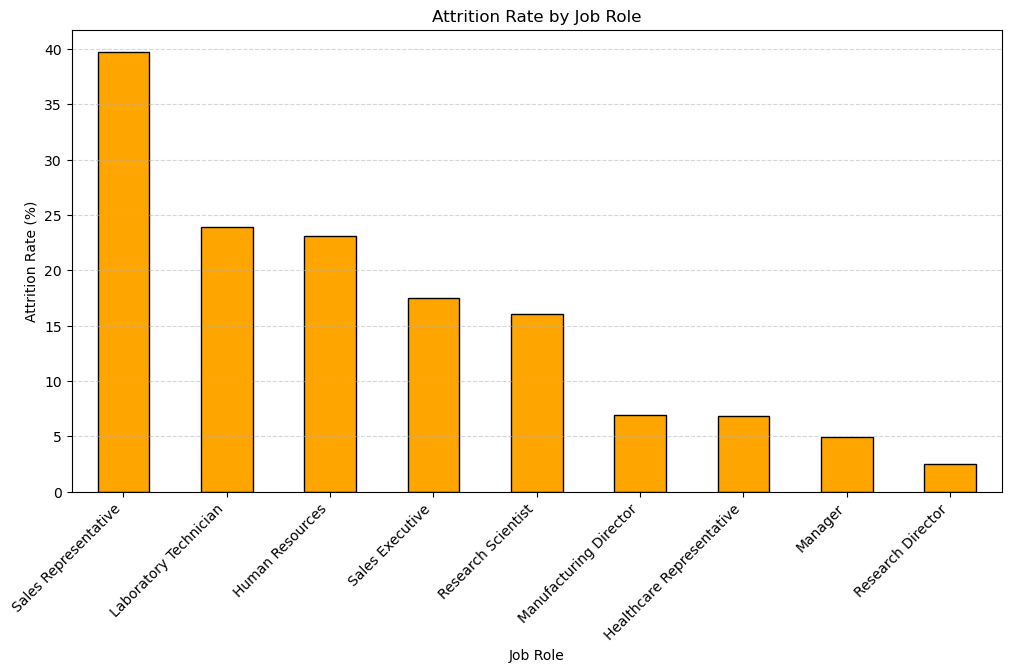

In [130]:
#Job Role-wise Attrition
jobrole = (
    df_original.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
jobrole.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig(
    "charts/attrition_by_jobrole.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 700x500 with 0 Axes>

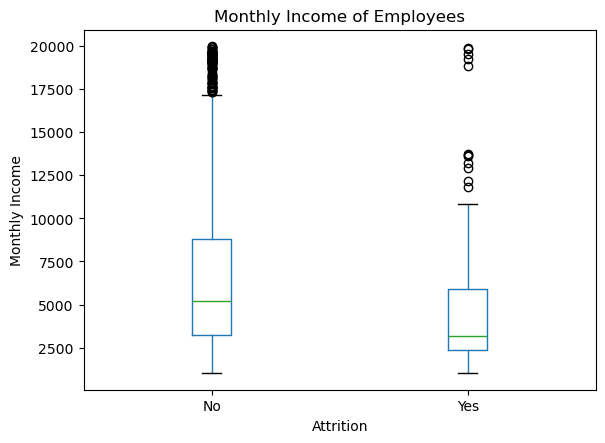

In [132]:
#Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(7,5))
df_original.boxplot(
    column="MonthlyIncome",
    by="Attrition",
    grid=False
)
plt.title("Monthly Income of Employees")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig(
    "charts/monthly_income_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [122]:
#Chart 3: Confusion Matrix heatmap for your best model
#Using the confusion matrix from Task 5.
cm = confusion_matrix(y_test, gb_pred)

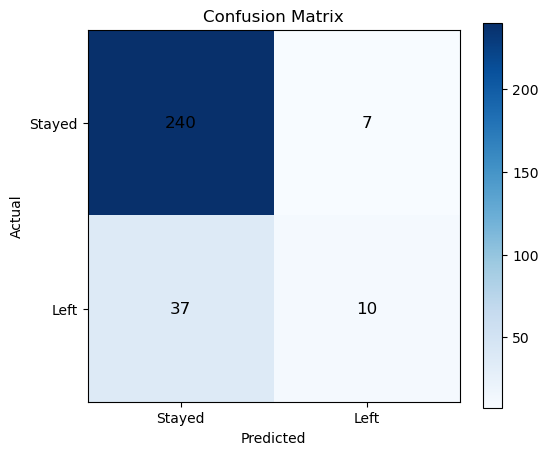

In [133]:
#Heatmap
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1],["Stayed","Left"])
plt.yticks([0,1],["Stayed","Left"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=12
        )
plt.colorbar()
plt.savefig(
    "charts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

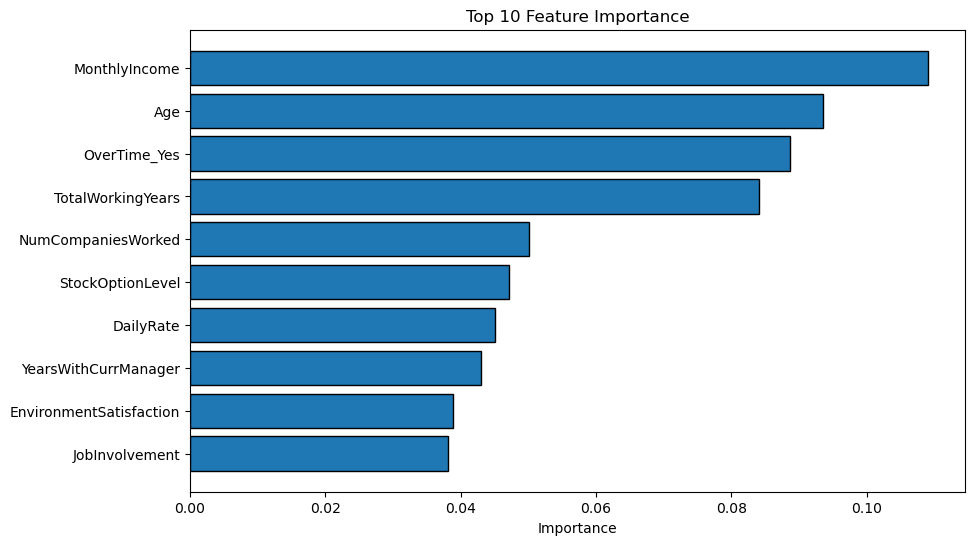

In [134]:
#Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
top10 = importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10["Feature"],
    top10["Importance"],
    edgecolor="black"
)
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.savefig(
    "charts/top10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [125]:
#Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

In [126]:
#Calculate Probabilities
log_prob = log_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]

In [127]:
#ROC Curves
from sklearn.metrics import roc_curve
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

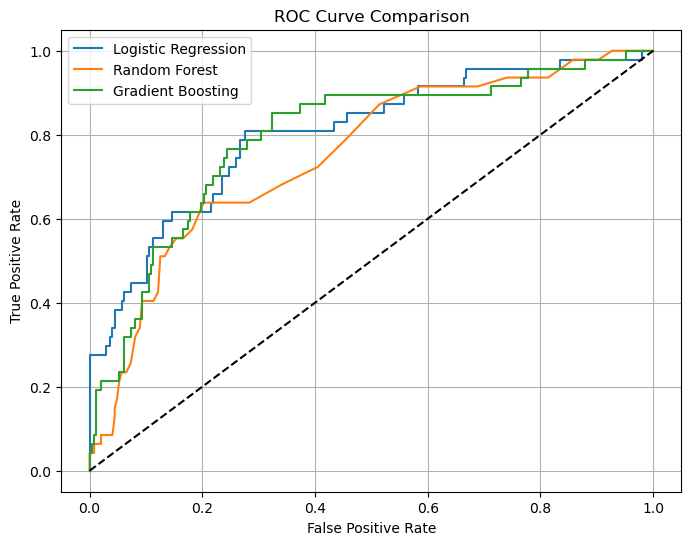

In [135]:
#Plot
plt.figure(figsize=(8,6))
plt.plot(
    log_fpr,
    log_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label="Gradient Boosting"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Task 7 — HR Insights & Business Recommendations

* Which 3 factors most strongly predict that an employee will leave?
Based on the feature importance analysis, the three most influential factors in predicting employee attrition are OverTime, MonthlyIncome, and Age (or the top three features shown in your feature importance chart if they differ slightly). Employees who work overtime frequently, earn lower salaries, or are relatively younger are more likely to leave the organization. These factors consistently contribute the most to the model's prediction of employee attrition.

* Which department or job role should HR prioritize for retention efforts?
The EDA shows that the Sales department experiences the highest attrition rate. Among job roles, Sales Representatives and Laboratory Technicians have the highest employee exit rates. HR should prioritize these departments and job roles by conducting regular employee engagement surveys, providing career development opportunities, and improving job satisfaction.

* Does salary alone explain attrition or are there other stronger factors?
Salary alone does not fully explain employee attrition. Although employees with lower monthly incomes tend to leave more frequently, other factors such as overtime, work-life balance, job satisfaction, years at the company, and career growth opportunities also significantly influence attrition. Therefore, employee retention should be addressed through a combination of compensation improvements and workplace policies.

* Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)
Recommendation 1 :
    HR should identify employees who frequently work overtime and provide flexible     work schedules, workload balancing, and wellness initiatives to reduce stress      and improve work-life balance.
Recommendation 2 :
    HR should focus on employees during their first three years in the company by      introducing structured onboarding programs, mentorship, regular career             discussions, and learning opportunities to improve long-term retention.

* What limitation does this model have that an HR team should be aware of before using it?
The model predicts employee attrition using historical HR data and cannot capture external factors such as personal circumstances, economic conditions, family commitments, or opportunities offered by other companies. Therefore, HR should use the model as a decision-support tool rather than relying solely on its predictions for employee retention decisions.

# Project Conclusion 

This project successfully developed a machine learning model to predict employee attrition using the IBM HR Analytics dataset. After preprocessing the data and comparing Logistic Regression, Random Forest, and Gradient Boosting classifiers, the Gradient Boosting Classifier achieved the best overall performance with an accuracy of approximately 85%. Exploratory Data Analysis revealed that attrition is strongly associated with factors such as overtime, monthly income, job role, department, and employee tenure. These insights can help HR departments proactively identify employees at risk of leaving and implement targeted retention strategies. While the model provides valuable decision support, it should be combined with human judgment and organizational policies to make effective workforce management decisions.